In [5]:
import stim
import re
import os
import pyzx as px
import matplotlib.pyplot as plt
import networkx as nx
from pyvis.network import Network

def stim_qasm_comply(qasm: str) -> str:
    q = qasm
    q = re.sub(r'def\s+rx\(qubit q0\)\s*\{[^}]*\}\n+', '', q)
    q = re.sub(r'rx\s*\(\s*q\[(\d+)\]\s*\)\s*;', r'h q[\1];', q)
    q = re.sub(r'reset\s+q\[(\d+)\];', '', q)
    return q



In [2]:
tableau = ["XZZXI", "IXZZX", "XIXZZ", "ZXIXZ"]
bug1 = ["+_Z_Z_","+_ZXZX","+_ZX_X"]
bug2 = ["-_XY_X", "-_XYXX", "-YXXXY"]

tableau_5_code = stim.Tableau.from_stabilizers([
    stim.PauliString("XZZXI"),
    stim.PauliString("IXZZX"), 
    stim.PauliString("XIXZZ"),
    stim.PauliString("ZXIXZ")
], allow_underconstrained=True)

g = px.universal_representation.tableau_to_graph_encoder(bug2)
px.draw(g)
g2 = px.universal_representation.graph_to_universal_representation(g)
px.draw(g2.graph, labels=True)
u = px.universal_representation.to_universal_graph_representation(g2)

print(u.adj)
# px.draw(g2.graph, labels=True)

# gra = g2.graph

# for v in gra.vertex_set():
#     if gra.type(v) == px.VertexType.BOUNDARY:
#         gra.remove_vertex(v)

# px.draw(gra, labels=True)

# gra.to_dict()


[stim.PauliString("-_XY_X"), stim.PauliString("-_XYXX"), stim.PauliString("-YXXXY")]
5 2


spider_simp: 7. 4. 3. 2. 2. 2.  6 iterations
id_simp: 3.  1 iterations
spider_simp: 2. 3. 2.  3 iterations
pivot_boundary_simp: 1.  1 iterations
lcomp_simp: 1. 1.  2 iterations


[[3], [4, 6], [4, 6], [6, 0], [2, 1, 6], [], [2, 4, 3, 1]]


In [3]:
tableau_5_code = stim.Tableau.from_stabilizers([
    stim.PauliString("XZZXI"),
    stim.PauliString("IXZZX"), 
    stim.PauliString("XIXZZ"),
    stim.PauliString("ZXIXZ")
], allow_underconstrained=True)

tableau_bit_code = stim.Tableau.from_stabilizers([
    stim.PauliString("ZZ_"),
    stim.PauliString("_ZZ"),
], allow_underconstrained=True)

# print(tableau_bit_code)
# print(tableau_5_code)

k = 1
n = 5

stabilizers = []

for i in range (n - k):
    stabilizers.append(stim.PauliString(f"Z{i}") * stim.PauliString(n+k))

for i in range(n-k, n): 
    stabilizers.append(stim.PauliString(f"Z{i}*Z{i+k}") * stim.PauliString(n+k)) 
    stabilizers.append(stim.PauliString(f"X{i}*X{i+k}") * stim.PauliString(n+k)) 


state = stim.TableauSimulator()
state.set_state_from_stabilizers(stabilizers)
state.do_tableau(tableau_5_code, range(n))

# print(state.current_inverse_tableau().inverse())
t = state.current_inverse_tableau().inverse()

qasm = t.to_circuit(method="graph_state").to_qasm(open_qasm_version=3)

# print(tableau_5_code)
pyzx_circ = Circuit.from_qasm(stim_qasm_comply(qasm))
# draw(pyzx_circ  )
g = pyzx_circ.to_graph()
input_state = "0"*(n+k)
# draw(g, labels=True)
inputs = g.outputs()[n:n+k]
outputs = g.outputs()[:n]
g.apply_state(input_state)
# clifford_simp(g)
# g.normalize()
# g.auto_detect_io()
# draw(g, labels=True )

# draw(g, labels=True)
# c = Circuit.from_graph(g)

# draw(c)


t0 = tensorfy(g)
# g = GraphState(g)
t1 = tensorfy(g)
# g.to_canonical_form()
t2 = tensorfy(g)

compare_tensors(t0, t2)

g = GraphState(g)
g.to_canonical_form()
# draw(g, labels=True)

d = to_universal_graph_representation(g, inputs)

d

# print(t0)

NameError: name 'Circuit' is not defined

In [4]:
def implement_encoder(d) -> Circuit:

    inputs = d["inputs"]
    adj = d["adjacency_list"]

    pivots = {i : -1 for i in inputs}

    out_to_in = {i : -1 for i in range(len(adj)) if i not in inputs}

    print(inputs)
    print(adj)

    for i in range(len(adj)):
        if i not in inputs:
            # print()
            neigh = adj[i]
            count = 0
            input = -1
            for n in neigh:
                if n in inputs:
                    count += 1
                    input = n
                    # print(n)
                    out_to_in[i] = n
            if count == 1:
                if pivots[input] == -1:
                    pivots[input] = i 

    
    n = len(adj)
    k = len(inputs)

    print(inputs)

    c = Circuit(n)

    c.add_gate("H", n-1)
    for i in range(n-2, k-1, -1):
        c.add_gate("CNOT", n-1, i)
    
    for i in inputs:
        for j in adj[i]:
            if j not in pivots.values():
                c.add_gate("CZ", i, j)
        
    for i in inputs:
        c.add_gate("H", i)

    for v in range(n):
        if v not in inputs:
            for u in adj[v]:
                if u not in inputs:
                    c.add_gate("CZ", v, u)
    
    draw(c, labels=True)

    return c
    



implement_encoder(d)

NameError: name 'Circuit' is not defined

In [ ]:
def to_distance_mzn(d):
    dzn = ""

    inputs = d["inputs"]
    dzn += f"I_nodes = {{{', '.join(str(x) for x in inputs)}}};\n"
    dzn += f"O_P_nodes = {{{', '.join(str(x) for x in range(len(d['adjacency_list'])) if x not in inputs)}}};\n"

    dzn += f"adj = [|"

    for i in range(len(d['adjacency_list'])):
        row = ""
        for j in range(len(d['adjacency_list'])):
            if j in d['adjacency_list'][i]:
                row += "true, "
            else:
                row += "false, "
        dzn += row[:-2] + "|\n"

    dzn += "];\n"

    dzn += "initial_lights = array1d(O_P_nodes, ["
    for i in range(len(d['adjacency_list'])):
        if i not in inputs:
            row = "0, "
            dzn += row
    dzn += "]);\n"

    return dzn


print(to_distance_mzn(d))

I_nodes = {0};
O_P_nodes = {1, 2, 3, 4, 5};
adj = [|false, true, true, true, true, true|
true, false, true, false, false, true|
true, true, false, true, false, false|
true, false, true, false, true, false|
true, false, false, true, false, true|
true, true, false, false, true, false|
];
initial_lights = array1d(O_P_nodes, [0, 0, 0, 0, 0, ]);



In [ ]:

qasm_5qubit = tableau_5_code.to_circuit(method="elimination").to_qasm(open_qasm_version=3)

qasm_bit = tableau_bit_code = stim.Tableau.from_stabilizers([
    stim.PauliString("ZZ_"),
    stim.PauliString("_ZZ"),
], allow_underconstrained=True).to_circuit(method="elimination").to_qasm(open_qasm_version=3)

pyzx_circ = Circuit.from_qasm(qasm_5qubit)
g = pyzx_circ.to_graph()
input_state = "0"*(3) + "/"*2
g.apply_state(input_state)


g.auto_detect_io()

g = GraphState(g)
s1 = tensorfy(g)
# draw(g, labels=True )
# draw(g, labels=True)


g.to_canonical_form()
# g = g.state_to_map()
s2 = tensorfy(g)
# print(t2)
compare_tensors(t2, s2, preserve_scalar=False)

False

In [ ]:
# qasm = tableau_5_code.to_circuit(method="elimination").to_qasm(open_qasm_version=3)
pyzx_circ = Circuit.from_qasm(stim_qasm_comply(qasm))
g = pyzx_circ.to_graph()
input_state = "0"*(6)
g.apply_state(input_state) 
g.auto_detect_io()
inputs = g.outputs()[5:6]
print(inputs)
to_universal_representation(g, inputs)


(49,)
(49,)


In [ ]:

qasm_5qubit = stim.Tableau.from_stabilizers([
    stim.PauliString("XZZXI"),
    stim.PauliString("IXZZX"), 
    stim.PauliString("XIXZZ"),
    stim.PauliString("ZXIXZ")
], allow_underconstrained=True).to_circuit(method="elimination").to_qasm(open_qasm_version=3)

shor_code = stim.Tableau.from_stabilizers([
    stim.PauliString("ZZIIIIIII"),
    stim.PauliString("ZIZIIIIII"),
    stim.PauliString("IIIZZIIII"),
    stim.PauliString("IIIZIZIII"),
    stim.PauliString("IIIIIIZZI"),
    stim.PauliString("IIIIIIZIZ"),
    stim.PauliString("XXXXXXIII"),
    stim.PauliString("IIIXXXXXX"),
], allow_underconstrained=True).to_circuit().to_qasm(open_qasm_version=3)

qasm_7qubit = stim.Tableau.from_stabilizers([
    stim.PauliString("IIIXXXX"),
    stim.PauliString("IXXIIXX"),
    stim.PauliString("XIXIXIX"),
    stim.PauliString("IIIZZZZ"),
    stim.PauliString("IZZIIZZ"),
    stim.PauliString("ZIZIZIZ")
], allow_underconstrained=True).to_circuit().to_qasm(open_qasm_version=3) 


In [ ]:

pyzx_circ = Circuit.from_qasm(qasm_5qubit)
g = pyzx_circ.to_graph()
input_state = "0"*(4) + "/"*1
g.apply_state(input_state)
d = to_universal_graph_representation(g)

TypeError: to_universal_graph_representation() missing 1 required positional argument: 'inputs'

[0]


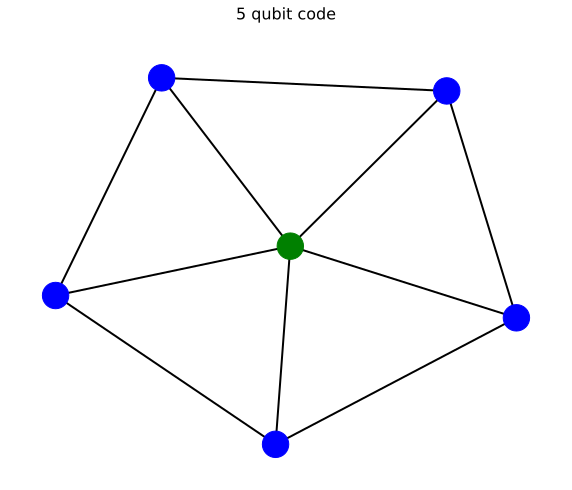

In [ ]:
print(u.inputs)

nxg = nx.Graph()
bounds = []
for v in range(len(u.adj)):
    # v_type = v["t"]
    if v in u.inputs:
        color = "green"
    else:
        color = "blue"
    # if v_type != VertexType.BOUNDARY:
    nxg.add_node(v, 
                color=color, 
                )
    # else:
    # bounds.append(v["id"])

adj = u.adj

for i in range(len(adj)):
    for j in adj[i]:
        if i < j:
            nxg.add_edge(i, j)
            nxg[i][j]['color'] = "black"
        
# for e in d["edges"]:
#     vertexes = d["vertices"]
#     edge_type = e[2]
#     edge_color = "red" if edge_type == EdgeType.HADAMARD else "black"
#     if e[0] not in bounds and e[1] not in bounds:
#         nxg.add_edge(e[0], e[1])
#         nxg[e[0]][e[1]]['color'] = edge_color

pos = nx.spring_layout(nxg, seed=42)  # nice spacing

node_colors = [nxg.nodes[n]['color'] for n in nxg.nodes()]
edge_colors = [nxg[u][v]['color'] for u,v in nxg.edges()]

# Draw the graph
plt.figure(figsize=(10,8))
nx.draw_networkx_nodes(nxg, pos, node_color=node_colors, node_size=700)
nx.draw_networkx_edges(nxg, pos, edge_color=edge_colors, width=2)
# nx.draw_networkx_labels(nxg, pos, font_size=10, font_color='white')

# Add title to the plot
plt.title("5 qubit code", fontsize=16, pad=20)

plt.axis('off')
plt.show()

net = Network(notebook=True, directed=False)
net.from_nx(nxg)


In [ ]:
from collections import defaultdict

class Pauli:

    # (a,b,c) represents i^a * X^b * Z^c
    def __init__ (self, a, b, c):
        self.a = a % 4
        self.b = b % 2
        self.c = c % 2

    def __mul__(self, other):
        s = (self.b * other.c - self.c * other.b) % 2 # commutation factor
        a = (self.a + other.a + 2*s) % 4 # phase
        b = (self.b + other.b) % 2 # X part
        c = (self.c + other.c) % 2 # Z part
        return GraphState.Pauli(a, b, c)

    def __repr__(self):
        phase = [1, 1j, -1, -1j][self.a]
        label = { (0,0):"I", (1,0):"X", (0,1):"Z", (1,1):"Y" }[(self.b,self.c)]
        return f"{phase}*{label}"


inputs = d["inputs"]
adj = d["adjacency_list"]

print(adj[2])

# sets = [set(adj[i]) for i in range(len(adj))]

# element_to_source = [[] for _ in range(len(adj))]

# for i in range(len(adj)):
#     for element in adj[i]:
#         element_to_source[element].append(i)

# print(element_to_source)
# pivots = [-1 for _ in range(len(adj))]

# for i in range(len(element_to_source)):
#     if len(element_to_source[i]) == 1:
#         pivots[i] = element_to_source[i][0]

# # for 

# print(element_to_source)

print(inputs)

pivots = {i : -1 for i in inputs}

out_to_in = {i : -1 for i in range(len(adj)) if i not in inputs}

print(inputs)
print(adj)

for i in range(len(adj)):
    if i not in inputs:
        # print()
        neigh = adj[i]
        count = 0
        input = -1
        for n in neigh:
            if n in inputs:
                count += 1
                input = n
                # print(n)
                out_to_in[i] = n
        if count == 1:
            if pivots[input] == -1:
                pivots[input] = i 

# print(out_to_in)


print("pivots", pivots.values())
print("out to in", out_to_in)



stabilizers = [[Pauli(0,0,0) for _ in range(len(adj) - len(inputs)) ] for _ in range(len(adj) - 2 * len(inputs))]

k = 0
for i in range(len(inputs), len(adj)):
    if i not in pivots.values():
        print("Scanning vertex", i)
        # print(k, i)
        stabilizers[k][i - len(inputs)] *= Pauli(0,1,0)
        print(stabilizers[k])
        for x in adj[i]:
            if x not in inputs:
                stabilizers[k][x - len(inputs)] *= Pauli(0,0,1)
        print(stabilizers[k])
        y = pivots[out_to_in[i]] 
        stabilizers[k][y - len(inputs)] *= Pauli(0,1,0)
        print(stabilizers[k])
        for x in adj[y]:
            if x not in inputs:
                stabilizers[k][x- len(inputs)] *= Pauli(0,0,1)
        print(stabilizers[k])
        k += 1

print(stabilizers)



[1, 3, 0]
[0]
[0]
[[2, 4, 5, 1, 3], [2, 0, 5], [1, 3, 0], [2, 4, 0], [5, 3, 0], [4, 0, 1]]
pivots dict_values([1])
out to in {1: 0, 2: 0, 3: 0, 4: 0, 5: 0}
Scanning vertex 2
[1*I, 1*X, 1*I, 1*I, 1*I]
[1*Z, 1*X, 1*Z, 1*I, 1*I]
[-1*Y, 1*X, 1*Z, 1*I, 1*I]
[-1*Y, -1*Y, 1*Z, 1*I, 1*Z]
Scanning vertex 3
[1*I, 1*I, 1*X, 1*I, 1*I]
[1*I, 1*Z, 1*X, 1*Z, 1*I]
[1*X, 1*Z, 1*X, 1*Z, 1*I]
[1*X, 1*I, 1*X, 1*Z, 1*Z]
Scanning vertex 4
[1*I, 1*I, 1*I, 1*X, 1*I]
[1*I, 1*I, 1*Z, 1*X, 1*Z]
[1*X, 1*I, 1*Z, 1*X, 1*Z]
[1*X, 1*Z, 1*Z, 1*X, 1*I]
Scanning vertex 5
[1*I, 1*I, 1*I, 1*I, 1*X]
[1*Z, 1*I, 1*I, 1*Z, 1*X]
[-1*Y, 1*I, 1*I, 1*Z, 1*X]
[-1*Y, 1*Z, 1*I, 1*Z, -1*Y]
[[-1*Y, -1*Y, 1*Z, 1*I, 1*Z], [1*X, 1*I, 1*X, 1*Z, 1*Z], [1*X, 1*Z, 1*Z, 1*X, 1*I], [-1*Y, 1*Z, 1*I, 1*Z, -1*Y]]
